# VAE with Implicit Reparameterization Gradients

Reproduction of Table 4 and Figure 4 from [Figurnov et al., "Implicit Reparameterization Gradients" (NeurIPS 2018)](https://arxiv.org/abs/1805.08498).

We train VAEs on dynamically binarized MNIST with different latent distributions:
- **Normal** prior N(0,1), posterior N(mu, sigma^2)
- **Gamma** prior Gamma(0.3, 0.3), posterior Gamma(alpha, beta)
- **Beta** prior Uniform(0,1), posterior Beta(alpha, beta)
- **VonMises** prior Uniform(-pi, pi), posterior VonMises(mu, kappa)

Architecture follows Davidson et al. (2018): FC ReLU encoder (256, 128) and decoder (128, 256).

In [1]:
import sys
import math
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
from collections import defaultdict
import warnings
warnings.filterwarnings("ignore")

sys.path.append("../src")
from irt.distributions import Normal, Gamma, Beta, VonMises

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Device: cuda
GPU: NVIDIA GeForce RTX 3090


## 1. Data: Dynamically Binarized MNIST

In [2]:
def dynamic_binarize(x):
    return torch.bernoulli(x)

transform = transforms.ToTensor()
train_dataset = datasets.MNIST("../data", train=True, download=True, transform=transform)
test_dataset = datasets.MNIST("../data", train=False, download=True, transform=transform)

BATCH_SIZE = 64
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f"Train: {len(train_dataset)}, Test: {len(test_dataset)}")

Train: 60000, Test: 10000


## 2. Model Architecture

Encoder: 784 -> 256 -> 128 -> latent parameters  
Decoder: D -> 128 -> 256 -> 784

In [3]:
class Encoder(nn.Module):
    def __init__(self, n_latent, n_params=2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(784, 256), nn.ReLU(),
            nn.Linear(256, 128), nn.ReLU(),
        )
        self.heads = nn.ModuleList([nn.Linear(128, n_latent) for _ in range(n_params)])

    def forward(self, x):
        h = self.net(x.view(x.size(0), -1))
        return [head(h) for head in self.heads]


class Decoder(nn.Module):
    def __init__(self, n_latent, input_dim=None):
        super().__init__()
        d = input_dim if input_dim is not None else n_latent
        self.net = nn.Sequential(
            nn.Linear(d, 128), nn.ReLU(),
            nn.Linear(128, 256), nn.ReLU(),
            nn.Linear(256, 784),
        )

    def forward(self, z):
        return self.net(z)


# ---- KL divergence functions ----

def kl_normal(mu, log_sigma):
    """KL(N(mu, sigma^2) || N(0, 1))"""
    return 0.5 * (mu.pow(2) + log_sigma.exp().pow(2) - 1 - 2 * log_sigma).sum(dim=-1)


def kl_gamma(alpha, beta, alpha0, beta0):
    """KL(Gamma(alpha, beta) || Gamma(alpha0, beta0))"""
    return (
        (alpha - alpha0) * torch.digamma(alpha)
        - torch.lgamma(alpha) + torch.lgamma(alpha0)
        + alpha0 * (torch.log(beta) - torch.log(beta0))
        + alpha * (beta0 - beta) / beta
    ).sum(dim=-1)


def kl_beta(a, b, a0, b0):
    """KL(Beta(a,b) || Beta(a0,b0))"""
    return (
        torch.lgamma(a0) + torch.lgamma(b0) - torch.lgamma(a0 + b0)
        - torch.lgamma(a) - torch.lgamma(b) + torch.lgamma(a + b)
        + (a - a0) * torch.digamma(a)
        + (b - b0) * torch.digamma(b)
        + (a0 - a + b0 - b) * torch.digamma(a + b)
    ).sum(dim=-1)


SOFTPLUS_LO, SOFTPLUS_HI = math.log(1e-3), math.log(1e3)

def clamp_positive(x):
    """Softplus with clipping to [1e-3, 1e3] as per the paper (Appendix D)."""
    return F.softplus(x).clamp(1e-3, 1e3)

## 3. VAE Classes for Each Distribution

In [4]:
class NormalVAE(nn.Module):
    """VAE with Normal(0,1) prior and Normal(mu, sigma^2) posterior."""
    name = "Normal"

    def __init__(self, n_latent):
        super().__init__()
        self.encoder = Encoder(n_latent, n_params=2)
        self.decoder = Decoder(n_latent)
        self.n_latent = n_latent

    def forward(self, x, kl_weight=1.0):
        mu, log_sigma = self.encoder(x)
        dist = Normal(mu, log_sigma.exp().clamp(1e-3, 1e3))
        z = dist.rsample()
        logits = self.decoder(z)
        recon = F.binary_cross_entropy_with_logits(logits, x.view(-1, 784), reduction="none").sum(-1)
        kl = kl_normal(mu, log_sigma)
        return (recon + kl_weight * kl).mean(), recon.mean(), kl.mean()

    @torch.no_grad()
    def sample(self, n, device):
        z = torch.randn(n, self.n_latent, device=device)
        return torch.sigmoid(self.decoder(z)).view(-1, 1, 28, 28)

    @torch.no_grad()
    def encode(self, x):
        mu, _ = self.encoder(x)
        return mu


class GammaVAE(nn.Module):
    """VAE with Gamma(a0, b0) prior and Gamma(alpha, beta) posterior."""
    def __init__(self, n_latent, a0=0.3, b0=0.3):
        super().__init__()
        self.name = f"Gamma({a0},{b0})"
        self.encoder = Encoder(n_latent, n_params=2)
        self.decoder = Decoder(n_latent)
        self.n_latent = n_latent
        self.a0, self.b0 = a0, b0

    def forward(self, x, kl_weight=1.0):
        raw_a, raw_b = self.encoder(x)
        alpha = clamp_positive(raw_a)
        beta = clamp_positive(raw_b)
        dist = Gamma(alpha, beta)
        z = dist.rsample()
        logits = self.decoder(z)
        recon = F.binary_cross_entropy_with_logits(logits, x.view(-1, 784), reduction="none").sum(-1)
        a0 = torch.tensor(self.a0, device=x.device)
        b0 = torch.tensor(self.b0, device=x.device)
        kl = kl_gamma(alpha, beta, a0, b0)
        return (recon + kl_weight * kl).mean(), recon.mean(), kl.mean()

    @torch.no_grad()
    def sample(self, n, device):
        a0, b0 = self.a0, self.b0
        z = Gamma(torch.full((n, self.n_latent), a0, device=device),
                  torch.full((n, self.n_latent), b0, device=device)).rsample()
        return torch.sigmoid(self.decoder(z)).view(-1, 1, 28, 28)

    @torch.no_grad()
    def encode(self, x):
        raw_a, raw_b = self.encoder(x)
        return clamp_positive(raw_a) / clamp_positive(raw_b)  # mean of Gamma


class BetaVAE(nn.Module):
    """VAE with Beta(a0, b0) prior and Beta(alpha, beta) posterior."""
    def __init__(self, n_latent, a0=1.0, b0=1.0):
        super().__init__()
        self.name = f"Beta({a0},{b0})" if a0 != 1.0 else "Beta(uniform)"
        self.encoder = Encoder(n_latent, n_params=2)
        self.decoder = Decoder(n_latent)
        self.n_latent = n_latent
        self.a0, self.b0 = a0, b0

    def forward(self, x, kl_weight=1.0):
        raw_a, raw_b = self.encoder(x)
        alpha = clamp_positive(raw_a)
        beta_param = clamp_positive(raw_b)
        dist = Beta(alpha, beta_param)
        z = dist.rsample()
        logits = self.decoder(z)
        recon = F.binary_cross_entropy_with_logits(logits, x.view(-1, 784), reduction="none").sum(-1)
        a0 = torch.tensor(self.a0, device=x.device)
        b0 = torch.tensor(self.b0, device=x.device)
        kl = kl_beta(alpha, beta_param, a0, b0)
        return (recon + kl_weight * kl).mean(), recon.mean(), kl.mean()

    @torch.no_grad()
    def sample(self, n, device):
        z = Beta(torch.full((n, self.n_latent), self.a0, device=device),
                 torch.full((n, self.n_latent), self.b0, device=device)).rsample()
        return torch.sigmoid(self.decoder(z)).view(-1, 1, 28, 28)

    @torch.no_grad()
    def encode(self, x):
        raw_a, raw_b = self.encoder(x)
        a, b = clamp_positive(raw_a), clamp_positive(raw_b)
        return a / (a + b)  # mean of Beta


class VonMisesVAE(nn.Module):
    """VAE with VonMises prior and VonMises(mu, kappa) posterior.
    Latent representation: (cos(z), sin(z)) as per the paper (Appendix D)."""
    def __init__(self, n_latent, kappa0=0.0):
        super().__init__()
        self.name = "VonMises(uniform)" if kappa0 == 0.0 else f"VonMises(0,{kappa0})"
        self.encoder = Encoder(n_latent, n_params=2)
        # Decoder input is 2*D because we use (cos(z), sin(z))
        self.decoder = Decoder(n_latent, input_dim=2 * n_latent)
        self.n_latent = n_latent
        self.kappa0 = kappa0

    def forward(self, x, kl_weight=1.0):
        raw_mu, raw_kappa = self.encoder(x)
        # mu = atan2(x, y) for unconstrained parameterization
        mu = raw_mu  # angle in radians
        kappa = clamp_positive(raw_kappa)
        dist = VonMises(mu, kappa)
        z = dist.rsample()
        # Map to (cos, sin) representation
        z_repr = torch.cat([torch.cos(z), torch.sin(z)], dim=-1)
        logits = self.decoder(z_repr)
        recon = F.binary_cross_entropy_with_logits(logits, x.view(-1, 784), reduction="none").sum(-1)
        # KL via sampling: KL = E_q[log q - log p]
        log_q = dist.log_prob(z).sum(-1)
        if self.kappa0 == 0.0:
            log_p = -self.n_latent * math.log(2 * math.pi)  # Uniform(-pi, pi)
        else:
            prior = VonMises(torch.zeros_like(mu), torch.full_like(kappa, self.kappa0))
            log_p = prior.log_prob(z).sum(-1)
        kl = log_q - log_p
        return (recon + kl_weight * kl).mean(), recon.mean(), kl.mean()

    @torch.no_grad()
    def sample(self, n, device):
        if self.kappa0 == 0.0:
            z = torch.rand(n, self.n_latent, device=device) * 2 * math.pi - math.pi
        else:
            z = VonMises(torch.zeros(n, self.n_latent, device=device),
                         torch.full((n, self.n_latent), self.kappa0, device=device)).sample()
        z_repr = torch.cat([torch.cos(z), torch.sin(z)], dim=-1)
        return torch.sigmoid(self.decoder(z_repr)).view(-1, 1, 28, 28)

    @torch.no_grad()
    def encode(self, x):
        raw_mu, _ = self.encoder(x)
        return raw_mu

## 4. Training and Evaluation

In [5]:
def train_epoch(model, loader, optimizer, device, kl_weight=1.0):
    model.train()
    total_loss, total_recon, total_kl, n = 0, 0, 0, 0
    for x, _ in loader:
        x = dynamic_binarize(x).to(device)
        loss, recon, kl = model(x, kl_weight=kl_weight)
        optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        optimizer.step()
        total_loss += loss.item() * x.size(0)
        total_recon += recon.item() * x.size(0)
        total_kl += kl.item() * x.size(0)
        n += x.size(0)
    return total_loss / n, total_recon / n, total_kl / n


@torch.no_grad()
def eval_nll(model, loader, device, n_importance=500):
    """Estimate test NLL via importance sampling (as in the paper)."""
    model.eval()
    total_nll, n = 0.0, 0
    for x, _ in loader:
        x = dynamic_binarize(x).to(device)
        # Single-sample ELBO estimate (matches paper: "single-sample estimate of ELBO")
        loss, _, _ = model(x, kl_weight=1.0)
        total_nll += loss.item() * x.size(0)
        n += x.size(0)
    return total_nll / n


def train_vae(model, train_loader, test_loader, device, lr=1e-3, epochs=50, kl_anneal_steps=50000):
    """Train VAE with KL annealing (linearly from 0 to 1 over kl_anneal_steps mini-batches)."""
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    step = 0
    steps_per_epoch = len(train_loader)

    for epoch in range(1, epochs + 1):
        model.train()
        total_loss, n = 0.0, 0
        for x, _ in train_loader:
            x = dynamic_binarize(x).to(device)
            kl_weight = min(1.0, step / kl_anneal_steps)
            loss, recon, kl = model(x, kl_weight=kl_weight)
            optimizer.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            optimizer.step()
            total_loss += loss.item() * x.size(0)
            n += x.size(0)
            step += 1

        if epoch % 10 == 0 or epoch == 1:
            test_nll = eval_nll(model, test_loader, device)
            print(f"  Epoch {epoch:3d} | Train loss: {total_loss/n:.1f} | Test NLL: {test_nll:.1f} | kl_w: {kl_weight:.2f}")

    test_nll = eval_nll(model, test_loader, device)
    return test_nll

## 5. Run Experiments (Table 4 from the paper)

Training all distribution/dimension configurations. This takes approximately 20-30 minutes on a GPU.

In [6]:
LATENT_DIMS = [2, 10, 20]
EPOCHS = 30
LR = 1e-3
KL_ANNEAL = 30000  # anneal KL weight over this many steps

def make_models(D):
    return [
        NormalVAE(D),
        GammaVAE(D, a0=0.3, b0=0.3),
        BetaVAE(D, a0=1.0, b0=1.0),     # Uniform prior
        VonMisesVAE(D, kappa0=0.0),       # Uniform prior
    ]

# Store results: {(name, D): nll}
results = {}
trained_models = {}

for D in LATENT_DIMS:
    print(f"\n{'='*60}")
    print(f"  Latent dimension D = {D}")
    print(f"{'='*60}")
    for model in make_models(D):
        print(f"\n--- {model.name}, D={D} ---")
        nll = train_vae(model, train_loader, test_loader, DEVICE, lr=LR, epochs=EPOCHS, kl_anneal_steps=KL_ANNEAL)
        results[(model.name, D)] = nll
        if D == 2:
            trained_models[model.name] = model
        print(f"  Final test NLL: {nll:.1f}")


  Latent dimension D = 2

--- Normal, D=2 ---


  Epoch   1 | Train loss: 170.6 | Test NLL: 172.9 | kl_w: 0.03


  Epoch  10 | Train loss: 139.3 | Test NLL: 145.5 | kl_w: 0.31


  Epoch  20 | Train loss: 138.6 | Test NLL: 141.8 | kl_w: 0.63


  Epoch  30 | Train loss: 139.7 | Test NLL: 140.3 | kl_w: 0.94


...

  Epoch   1 | Train loss: 156.1 | Test NLL: 169.1 | kl_w: 0.03


  Epoch  10 | Train loss: 88.3 | Test NLL: 123.5 | kl_w: 0.31


  Epoch  20 | Train loss: 97.2 | Test NLL: 113.2 | kl_w: 0.63


  Epoch  30 | Train loss: 106.0 | Test NLL: 108.3 | kl_w: 0.94


  Final test NLL: 108.2


## 6. Results Table (cf. Table 4 in the paper)

Test negative ELBO (lower is better):

           Prior           Posterior   D=2  D=10  D=20
          N(0,1)      N(mu, sigma^2) 140.3 101.8  98.9
 Gamma(0.3, 0.3)  Gamma(alpha, beta) 140.8 106.9 105.4
    Uniform(0,1)   Beta(alpha, beta) 144.0 107.1 104.8
Uniform(-pi, pi) VonMises(mu, kappa) 141.8 107.7 108.2


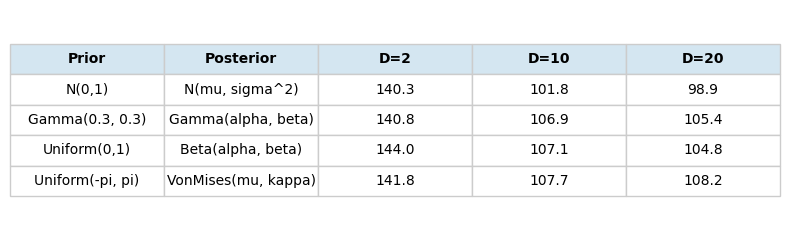

Saved to images/results_table.png


In [7]:
import pandas as pd

model_names = ["Normal", "Gamma(0.3,0.3)", "Beta(uniform)", "VonMises(uniform)"]
prior_labels = ["N(0,1)", "Gamma(0.3, 0.3)", "Uniform(0,1)", "Uniform(-pi, pi)"]
posterior_labels = ["N(mu, sigma^2)", "Gamma(alpha, beta)", "Beta(alpha, beta)", "VonMises(mu, kappa)"]

rows = []
for name, prior, posterior in zip(model_names, prior_labels, posterior_labels):
    row = {"Prior": prior, "Posterior": posterior}
    for D in LATENT_DIMS:
        nll = results.get((name, D), float("nan"))
        row[f"D={D}"] = f"{nll:.1f}"
    rows.append(row)

df = pd.DataFrame(rows)
print("Test negative ELBO (lower is better):\n")
print(df.to_string(index=False))

# Save as PNG table
fig, ax = plt.subplots(figsize=(8, 2.5))
ax.axis("off")
col_labels = ["Prior", "Posterior"] + [f"D={D}" for D in LATENT_DIMS]
cell_text = [[row["Prior"], row["Posterior"]] + [row[f"D={D}"] for D in LATENT_DIMS] for _, row in df.iterrows()]
table = ax.table(cellText=cell_text, colLabels=col_labels, loc="center", cellLoc="center")
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.0, 1.6)
for key, cell in table.get_celld().items():
    if key[0] == 0:
        cell.set_facecolor("#d4e6f1")
        cell.set_text_props(weight="bold")
    cell.set_edgecolor("#cccccc")
fig.tight_layout()
fig.savefig("../images/results_table.png", dpi=150, bbox_inches="tight", facecolor="white")
plt.show()
print("Saved to images/results_table.png")

## 7. 2D Latent Space Visualization (cf. Figure 4 in the paper)

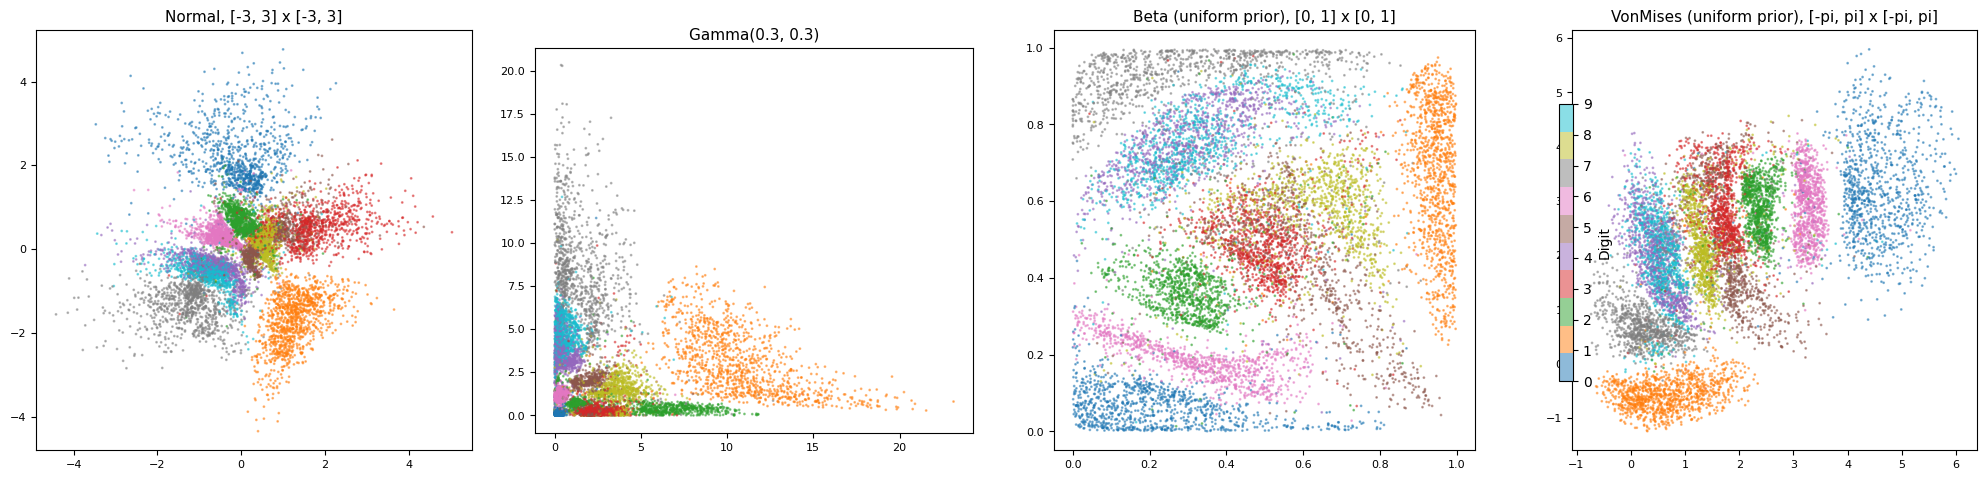

Saved to ../images/latent_spaces.png


In [8]:
@torch.no_grad()
def plot_latent_spaces(models_dict, test_loader, device, save_path="../images/latent_spaces.png"):
    """Plot 2D latent space encodings colored by digit class."""
    # Collect encodings and labels
    encodings = {}
    labels_all = None
    for name, model in models_dict.items():
        model.eval()
        zs, ys = [], []
        for x, y in test_loader:
            x = x.to(device)
            z = model.encode(x)
            zs.append(z.cpu())
            ys.append(y)
        encodings[name] = torch.cat(zs, 0).numpy()
        if labels_all is None:
            labels_all = torch.cat(ys, 0).numpy()

    fig, axes = plt.subplots(1, len(models_dict), figsize=(5 * len(models_dict), 4.5))
    if len(models_dict) == 1:
        axes = [axes]

    cmap = plt.cm.tab10
    titles = {
        "Normal": "Normal, [-3, 3] x [-3, 3]",
        "Beta(uniform)": "Beta (uniform prior), [0, 1] x [0, 1]",
        "VonMises(uniform)": "VonMises (uniform prior), [-pi, pi] x [-pi, pi]",
        "Gamma(0.3,0.3)": "Gamma(0.3, 0.3)",
    }

    for ax, (name, z) in zip(axes, encodings.items()):
        sc = ax.scatter(z[:, 0], z[:, 1], c=labels_all, cmap=cmap, s=1, alpha=0.5, vmin=0, vmax=9)
        ax.set_title(titles.get(name, name), fontsize=11)
        ax.set_aspect("equal")
        ax.tick_params(labelsize=8)

    fig.colorbar(sc, ax=axes, ticks=range(10), label="Digit", shrink=0.8)
    fig.tight_layout()
    fig.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved to {save_path}")

plot_latent_spaces(trained_models, test_loader, DEVICE)

## 8. Generated Samples

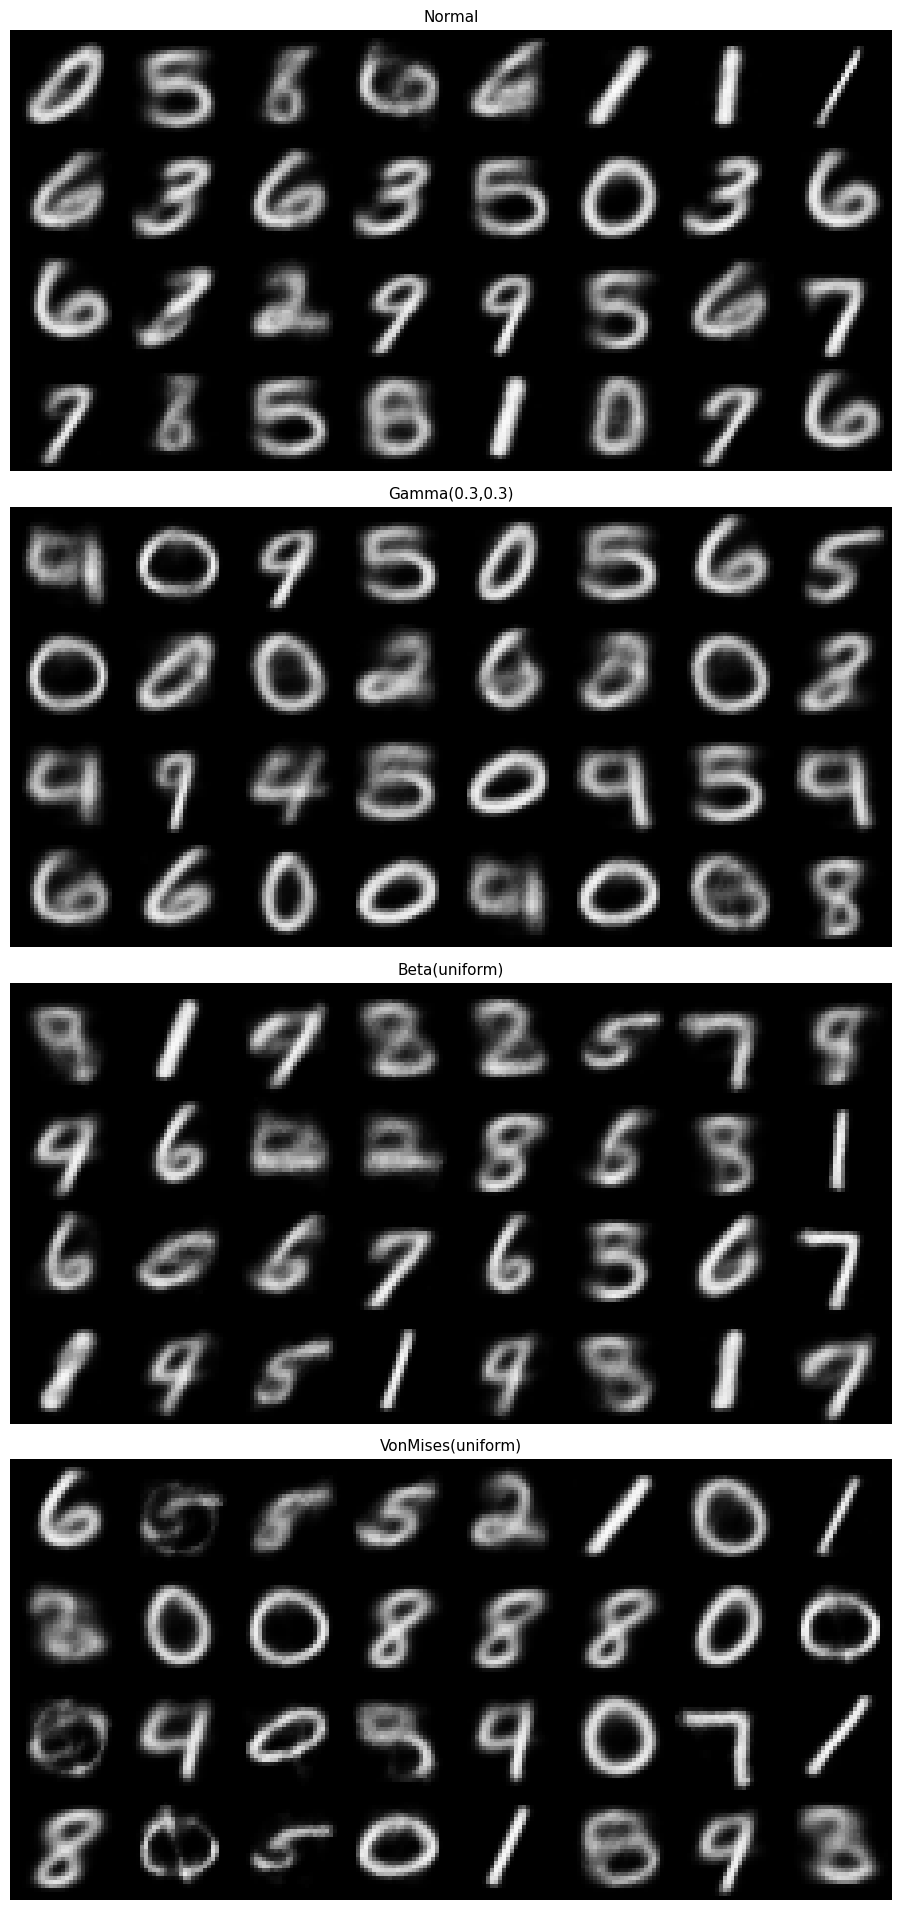

Saved to ../images/generated_samples.png


In [9]:
@torch.no_grad()
def plot_samples(models_dict, device, n_rows=4, n_cols=8, save_path="../images/generated_samples.png"):
    """Generate and plot samples from each trained D=2 model."""
    n = n_rows * n_cols
    fig, axes = plt.subplots(len(models_dict), 1, figsize=(n_cols * 1.2, n_rows * 1.2 * len(models_dict)))
    if len(models_dict) == 1:
        axes = [axes]

    for ax, (name, model) in zip(axes, models_dict.items()):
        model.eval()
        imgs = model.sample(n, device).cpu()
        grid = torch.zeros(n_rows * 28, n_cols * 28)
        for i in range(n_rows):
            for j in range(n_cols):
                grid[i*28:(i+1)*28, j*28:(j+1)*28] = imgs[i*n_cols+j, 0]
        ax.imshow(grid, cmap="gray", vmin=0, vmax=1)
        ax.set_title(name, fontsize=11)
        ax.axis("off")

    fig.tight_layout()
    fig.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved to {save_path}")

plot_samples(trained_models, DEVICE)